### **Lấy và làm sạch Dữ liệu AQI và Weather từ AQI**

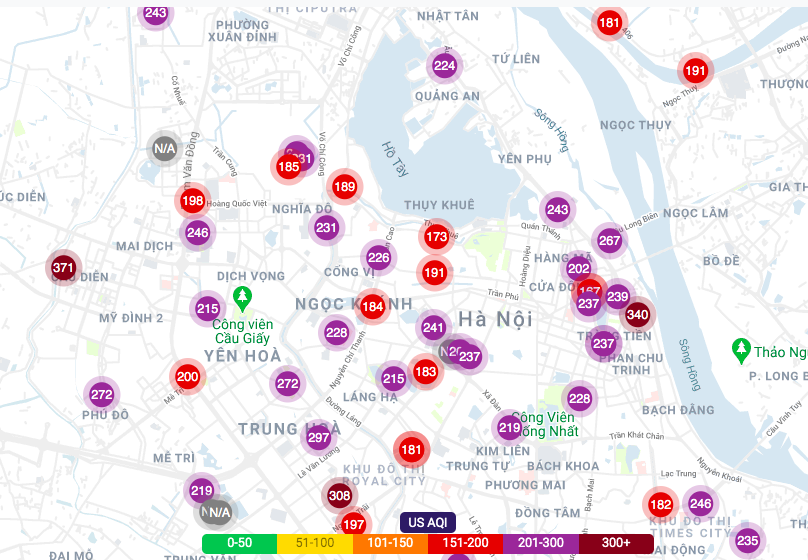

#### **I. Import các thư viện**

In [34]:
import requests
import json
import pandas as pd
import numpy as np
import datetime
from datetime import datetime, timedelta
from time import sleep
%matplotlib inline      

#### **II. Lấy dữ liệu từ API và tạo Dataframe từ data lấy được**
Trong dự án này, dữ liệu chất lượng không khí được thu thập thông qua [Weatherbit API](https://www.weatherbit.io/), một nền tảng tổng hợp dữ liệu khí tượng – môi trường toàn cầu.Weatherbit không trực tiếp đặt cảm biến tại từng vị trí địa lý, mà tổng hợp dữ liệu từ nhiều nguồn khác nhau, bao gồm:
- Các trạm quan trắc mặt đất (ground-based stations),

- Dữ liệu vệ tinh khí tượng (NASA MODIS, TROPOMI, MOPITT, v.v.),

- Và các mô hình khí tượng – hóa học (numerical models) như WRF-Chem, CAMS, GEOS-Chem.

Dữ liệu sau khi được thu thập sẽ được hiệu chỉnh sai số, nội suy không gian và chuẩn hóa theo từng ô lưới (grid) có kích thước khoảng 10 km × 10 km.
Điều này có nghĩa là các khu vực nằm trong cùng một ô lưới (ví dụ các quận nội thành Hà Nội nằm gần nhau) sẽ nhận được cùng một giá trị AQI và nồng độ các chất ô nhiễm (PM₂.₅, PM₁₀, CO, NO₂, SO₂, O₃).

Vì vậy, để tránh hiện tượng dữ liệu bị trùng lặp (nhân bản) giữa các quận lân cận, dự án lựa chọn tọa độ trung tâm của quận Hoàn Kiếm (21.0285°N, 105.8542°E) làm điểm đại diện cho khu vực nội thành Hà Nội. Hoàn Kiếm là khu vực trung tâm thủ đô, có mật độ dân cư cao, nhiều hoạt động giao thông và thương mại, do đó phản ánh tương đối chính xác chất lượng không khí trung bình của toàn khu vực đô thị Hà Nội.


In [35]:
# API_KEY = "d0abdba555a24c308b658ff1a9af5267"
API_KEY = "2f00584ccfcf401cb9dc025a40a0e799"
LAT, LON = 21.0285, 105.8542

start_date = datetime(2023, 1, 1)
end_date = datetime(2025, 1, 1, 0)

urls_air = []
urls_wea = []
current = start_date
while current < end_date:
    next_month = (current.replace(day=28) + timedelta(days=4)).replace(day=1)
    start_str = current.strftime('%Y-%m-%d')
    end_str = next_month.strftime('%Y-%m-%d')
    
    url_air = f"https://api.weatherbit.io/v2.0/history/airquality?lat={LAT}&lon={LON}&start_date={start_str}&end_date={end_str}&tz=local&key={API_KEY}"
    url_wea = f"https://api.weatherbit.io/v2.0/history/hourly?lat={LAT}&lon={LON}&start_date={start_str}&end_date={end_str}&tz=local&key={API_KEY}"
    urls_air.append(url_air)
    urls_wea.append(url_wea)
    current = next_month

print(f" Tạo{len(urls_air)} URLs ({urls_air[0]} → {urls_air[-1]})")
print(f" Tạo{len(urls_wea)} URLs ({urls_wea[0]} → {urls_wea[-1]})")
    

 Tạo24 URLs (https://api.weatherbit.io/v2.0/history/airquality?lat=21.0285&lon=105.8542&start_date=2023-01-01&end_date=2023-02-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799 → https://api.weatherbit.io/v2.0/history/airquality?lat=21.0285&lon=105.8542&start_date=2024-12-01&end_date=2025-01-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799)
 Tạo24 URLs (https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2023-01-01&end_date=2023-02-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799 → https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2024-12-01&end_date=2025-01-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799)


##### **2.1 AIR QUALITY**

In [36]:
# results_air = []
# for i, url in enumerate(urls_air):
#     print(f'Lấy dữ liệu từ URL {i}/{len(urls_air)} : {url}')
#     try:
#         renponse = requests.get(url, timeout=30)
#         renponse.raise_for_status()
#         data = json.loads(renponse.text)
#         results_air.append(data)
#         sleep(1.2)
        
#     except Exception as e:
#         print(f"Lỗi khi lấy dữ liệu {i} : {e}")
        
# print(f"\n Hoàn tất tải {len(results_air)} ")

In [37]:
# results_air[0]['city_name']

In [38]:


# results_air[0]['data'][0]

In [39]:
# joined_data = []
# for res in results_air:
#     if 'data' in res:
#         joined_data.extend(res['data'])
        
# joined_results = {
#     'city_name': results_air[0]['city_name'],
#     'country_code': results_air[0]['country_code'],
#     'lat': results_air[0]['lat'],
#     'lon': results_air[0]['lon'],
#     'timezone': results_air[0]['timezone'],
#     'data': joined_data
# }



In [40]:
# joined_results['data'][0]

In [41]:
# joined_results['data'][-1]

In [42]:

# df = pd.DataFrame(joined_results)

# df.columns = ['City', 'Country code', 'Lat', 'Lon', 'timezone', 'Data']
# df[['AQI', 'CO', 'Date Time', 'NO2', 'O3', 'PM10', 'PM25', 'SO2', 'Local Time', 'UTC Time', 'TS']] = pd.DataFrame(df['Data'].tolist())
# df.drop(columns=['Data', 'Lat', 'Lon', 'TS', 'Date Time'], inplace=True)
# df = df.drop_duplicates()
# df = df.sort_values(by='Local Time')
# df['Local Time'] = pd.to_datetime(df['Local Time'])
# df.set_index('Local Time', inplace=True)
# df.head()

In [43]:
# df.to_csv('air_quality_data.csv', index=True)

##### **2.2 WEATHER**

In [44]:
results_wea = []
for i, url in enumerate(urls_wea):
    print(f'Lấy dữ liệu từ URL {i}/{len(urls_wea)} : {url}')
    try:
        renponse = requests.get(url, timeout=30)
        renponse.raise_for_status()
        data = json.loads(renponse.text)
        results_wea.append(data)
        sleep(1.2)
        
    except Exception as e:
        print(f"Lỗi khi lấy dữ liệu {i} : {e}")
        
print(f"\n Hoàn tất tải {len(results_wea)} ")

Lấy dữ liệu từ URL 0/24 : https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2023-01-01&end_date=2023-02-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799


Lỗi khi lấy dữ liệu 0 : 429 Client Error: Too Many Requests for url: https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2023-01-01&end_date=2023-02-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799
Lấy dữ liệu từ URL 1/24 : https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2023-02-01&end_date=2023-03-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799
Lỗi khi lấy dữ liệu 1 : 429 Client Error: Too Many Requests for url: https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2023-02-01&end_date=2023-03-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799
Lấy dữ liệu từ URL 2/24 : https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2023-03-01&end_date=2023-04-01&tz=local&key=2f00584ccfcf401cb9dc025a40a0e799
Lỗi khi lấy dữ liệu 2 : 429 Client Error: Too Many Requests for url: https://api.weatherbit.io/v2.0/history/hourly?lat=21.0285&lon=105.8542&start_date=2023-03-01&end_date=202

KeyboardInterrupt: 

In [ ]:
joined_data = []
for res in results_wea:
    if 'data' in res:
        joined_data.extend(res['data'])
        
joined_results_weather = {
    'city_name': results_wea[0]['city_name'],
    'country_code': results_wea[0]['country_code'],
    'lat': results_wea[0]['lat'],
    'lon': results_wea[0]['lon'],
    'timezone': results_wea[0]['timezone'],
    'data': joined_data
}

In [ ]:

df_weather = pd.DataFrame(joined_results_weather)


df_weather.columns = ['City', 'Country code', 'Lat', 'Lon', 'timezone', 'Data']


df_weather[['Apparent Temperature', 'Azimuth', 'Clouds', 'Datetime', 'Dew Point', 'DHI', 'DNI', 'Elevation Angle', 'GHI',
            'H Angle', 'Pod', 'Precipitation', 'Pressure', 'Status', 'Relative Humidity', 'Sea Level Pressure', 'Snow',
            'Solar Radiation', 'Temperature', 'Local Time', 'UTC Time', 'Timestamp', 'UV Index', 'Visibility', 'Weather',
            'Wind Direction', 'Wind Gust Speed', 'Wind Speed']] = pd.DataFrame(df_weather['Data'].tolist())


df_weather.drop(columns=['Data', 'Lat', 'Lon', 'Apparent Temperature', 'Azimuth','Datetime', 'Dew Point', 'DHI', 'DNI',
                         'Elevation Angle', 'GHI', 'H Angle', 'Pod', 'Status', 'Sea Level Pressure', 'Snow',
                         'Solar Radiation', 'Timestamp', 'Visibility', 'Wind Direction', 'Wind Gust Speed', 'Weather'], inplace=True)


df_weather = df_weather.drop_duplicates()


df_weather = df_weather.sort_values(by='Local Time')


df_weather['Local Time'] = pd.to_datetime(df_weather['Local Time'])

df_weather.set_index('Local Time', inplace=True)


df_weather = df_weather[:-23]

df_weather
#df.head()

In [ ]:

df_weather.info()


#### **IV. Hợp nhất hai khung dữ liệu và sắp xếp dữ liệu**

In [ ]:
# #Merge two dataframes keeping the local datetime index
# merged_df = pd.merge(df, df_weather, left_index=True, right_index=True)
# #Drop duplicated columns
# merged_df.drop(columns=['City_y', 'Country code_y', 'timezone_y', 'UTC Time_y'], inplace=True)
# #Put UTC time column to the first column in the dataframe
# utc_time_column = merged_df.pop('UTC Time_x')
# merged_df.insert(0, 'UTC Time', utc_time_column)
# #Rename 4 columns
# merged_df = merged_df.rename(columns={'City_x': 'City', 'Country code_x': 'Country Code', 'timezone_x':'Timezone'})
# merged_df

In [ ]:
# merged_df.info()

In [ ]:

# merged_df.to_csv('hanoi-aqi-weather-data.csv')